In [1]:
import math, os

import numpy as np
import jax
from jax import Array
from jax import numpy as jnp
from jax import scipy as jsp
import matplotlib.pyplot as plt

import dynamiqs as dq

from blueprint.qubits import TunableTransmon, KerrOscillator, HarmonicOscillator
from blueprint.devices import Device
from blueprint.pulses import flux_pulses, coupler_pulses, charge_pulses
from blueprint.pulses.flux_pulses import net_zero_transition_flux_pulse
from blueprint.operators.basis import OperatorBasis
from blueprint.util.operators import get_pauli_ops
from blueprint.metrics import gate_fidelity

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.90"  # for 90% of total GPU memory

# jax.config.update("jax_default_device", jax.devices("cpu")[0])
#jax.config.update("jax_default_device", jax.devices("cuda")[1])
jax.config.update("jax_enable_x64", True)  # Double
dtype = jnp.complex128
# jax.config.update("jax_enable_x64", False)  # Simple
# dtype = jnp.complex64

/Users/varb2323/Projects/blueprint/.venv/lib/python3.12/site-packages/qutip/__init__.py:71: UserWarning: Runtime cython compilation does not work on Python 3.12.
  warnings.warn(


In [2]:
# units
kHz, MHz, GHz = 1e-6, 1e-3, 1
ns, us, ms = 1 * 2 * math.pi, 1e3 * 2 * math.pi, 1e6 * 2 * math.pi

## Qubit

In [3]:
LABEL = "Q1"
CHARGING_ENERGY = 0.17874386390652913 * GHz
JOSEPHSON_ENERGY = 28.045385714769342 * GHz
ASYMMETRY = 0.617379794210013
CHARGE_CUTOFF = 100
OFFSET_CHARGE = 0.0
EXT_FLUX = 0.0
dim = 5

transmon = TunableTransmon(
    label=LABEL,
    charging_energy=CHARGING_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    asymmetry=ASYMMETRY,
    charge_cutoff=CHARGE_CUTOFF,
    offset_charge=OFFSET_CHARGE,
    ext_flux=EXT_FLUX,
    relax_time=None,
    deph_time=None,
)

transmon.diagonalize(dim)

## Drives

In [4]:
transmon.add_charge_drive("cosine_drive", charge_pulses.cosine_pulse)
transmon.add_charge_drive("cosine_drag_pulse", charge_pulses.cosine_drag_pulse)

## Device

In [5]:
device = Device(
    [
        transmon,
    ]
)

device.index_eigenstates()

device.diagonalize()

## Build the time-dependent Hamiltonians

In [6]:
dq_static_hamiltonian = dq.constant(device.get_hamiltonian())

Let's do a $\pi$ gate in 30 ns

In [7]:
GATE_TIME_NS = 30 * ns
AMPLITUDE_GHZ = (2 * math.pi) / GATE_TIME_NS / float(jnp.abs(transmon.charge_zpf))
CARRIER_FREQ_GHZ = float(transmon.frequency)
# CARRIER_FREQ_GHZ = jnp.linspace(transmon.frequency, transmon.frequency + 0.001, 21)
CARRIER_PHASE = 0.0
DRAG_PARAM = 1 / 4 / (-float(transmon.anharmonicity))

AMPLITUDE_GHZ, CARRIER_FREQ_GHZ, DRAG_PARAM

(0.02273095307433338, 6.148527882389711, 1.3033166893356074)

### Cosine pulse, scanning the carrier frequency

In [20]:
carrier_freqs = jnp.linspace(transmon.frequency, transmon.frequency + 0.001, 21)

for prefactor, op in device.qubits[0]._drives["cosine_drive"].decompose():
    dq_hamiltonian_cos = dq_static_hamiltonian + dq.modulated(
        prefactor,
        op,
        args=(
            AMPLITUDE_GHZ,
            GATE_TIME_NS,
            CARRIER_FREQ_GHZ,
            CARRIER_PHASE,
        ),
    )

### Cosine pulse, scanning the carrier frequency

In [9]:
# carrier_freqs = jnp.linspace(transmon.frequency, transmon.frequency + 0.001, 21)
drag_params = jnp.linspace(DRAG_PARAM, DRAG_PARAM + 1., 41)

for prefactor, op in device.qubits[0]._drives["cosine_drag_pulse"].decompose():
    dq_hamiltonian_drag = dq_static_hamiltonian + dq.modulated(
        prefactor,
        device.process_op(op),
        args=(
            AMPLITUDE_GHZ,
            GATE_TIME_NS,
            6.148792591721474,
            drag_params,
            CARRIER_PHASE,
        ),
    )

# Single-qubit gate simulations

## Define the scope

In [21]:
# === tsave
tsave_pop = jnp.linspace(0, GATE_TIME_NS, 31)
tsave_ptm = jnp.linspace(0, GATE_TIME_NS, 2)

In [22]:
# === qubit operators and states
ket_0 = device.get_eigenstate(0)[1][:, None]
ket_1 = device.get_eigenstate(1)[1][:, None]
ket_2 = device.get_eigenstate(2)[1][:, None]
ket_3 = device.get_eigenstate(3)[1][:, None]

Id = ket_0 @ dq.dag(ket_0) + ket_1 @ dq.dag(ket_1)
X = ket_0 @ dq.dag(ket_1) + ket_1 @ dq.dag(ket_0)                 # X
Y = -1.0j * ket_0 @ dq.dag(ket_1) + 1.0j * ket_1 @ dq.dag(ket_0)  # Y
Z = ket_0 @ dq.dag(ket_0) - ket_1 @ dq.dag(ket_1)                 # Z

rho_pX = (Id + X) / 2
rho_mX = (Id - X) / 2
rho_pY = (Id + Y) / 2
rho_mY = (Id - Y) / 2
rho_pZ = (Id + Z) / 2
rho_mZ = (Id - Z) / 2
rho_0 = ket_0 @ dq.dag(ket_0)
rho_1 = ket_1 @ dq.dag(ket_1)
rho_2 = ket_2 @ dq.dag(ket_2)
rho_3 = ket_3 @ dq.dag(ket_3)

In [23]:
# === initial states for populations dynamics
rho0_pop = jnp.stack(
    [
        rho_pX,
        rho_mX,
        rho_pY,
        rho_mY,
        rho_pZ,
        rho_mZ,
        rho_2,
        rho_3,
    ]
)
rho0_pop.shape

(8, 5, 5)

In [24]:
# === initial states for Pauli Transfer Matrix
ops = jnp.stack(get_pauli_ops(normalize=True))
labels = ("I", "X", "Y", "Z")
basis = OperatorBasis(ops, labels)
basis = basis.expand_dim(device.dim)
rho0_ptm = basis.operators
rho0_ptm.shape

(4, 5, 5)

In [25]:
# === expectation operators for populations dynamics
exp_ops_pop = [X, Y, Z, rho_0, rho_1, rho_2, rho_3]

In [26]:
# === expectation operators for Pauli Transfer Matrix
# exp_ops_ptm = copy.deepcopy(rho0_ptm)

In [27]:
# === Trivial jump operator for now
jump_ops = [jnp.zeros((device.dim, device.dim))]

# Run the simulation

In [28]:
import time

In [29]:
# === expects in rotating frame: Need the H0 propagator
static_hamiltonian = device.get_hamiltonian()
if jnp.allclose(jnp.diag(jnp.diag(static_hamiltonian)), static_hamiltonian):
    U0s_diags = jnp.exp(
        1.0j * tsave_pop[:, None] * jnp.diagonal(static_hamiltonian)[None, :]
    )
    # Now embed in diags
    Nt, Ndim = U0s_diags.shape
    U0s = (
        jnp.zeros_like(U0s_diags, shape=(Nt, Ndim, Ndim))
        .at[:, jnp.arange(Ndim), jnp.arange(Ndim)]
        .set(U0s_diags)
    )
else:
    # WARNING: Seems to be very error-prone for float32 (complex64) precision
    U0s = jax.scipy.linalg.expm(
        1.0j * tsave_pop[:, None, None] * static_hamiltonian[None, :, :]
    )

## Cosine pulse

### Population dynamics

In [31]:
# === run mesolve
t0 = time.time()
result_pop = dq.mesolve(
    H=dq_hamiltonian_cos,
    jump_ops=jump_ops,
    rho0=rho0_pop,
    tsave=tsave_pop,
    exp_ops=None,
    #exp_ops=None,
    solver=dq.solver.Tsit5(rtol=1e-06, atol=1e-06, max_steps=10000),
    options=dq.Options(
        save_states=True,
        verbose=True,
    ),
)
tf = time.time()
print(f"Sim took {tf - t0:.2f} seconds.")
print(result_pop)

ValueError: Incompatible shapes for broadcasting: shapes=[(5, 5), (201, 201)]

In [20]:
# U0s: Shape ([time_len, *dims, *dims])
# result.states shape: (batch_size, time_len, *dims, *dims)
rhos_pop = U0s @ result_pop.states @ dq.dag(U0s)
# rhos_qb = jnp.einsum('tnm,btmk->btnk', U0s, result.states)
# rhos_qb shape: (batch_size, time_len, *dims, *dims)

# exp_ops: Shape (n_expt_values, *dims, *dims)
metrajs_pop = jnp.einsum("...tnm,emn->...et", rhos_pop, jnp.array(exp_ops_pop)).real
metrajs_pop.shape

(21, 8, 7, 31)

### Pauli Transfer Matrix

In [21]:
# === run mesolve
t0 = time.time()
result_ptm = dq.mesolve(
    H=dq_hamiltonian_cos,
    jump_ops=jump_ops,
    rho0=rho0_ptm,
    tsave=tsave_ptm,
    exp_ops=None,
    solver=dq.solver.Tsit5(rtol=1e-06, atol=1e-06, max_steps=10000),
    options=dq.Options(
        save_states=True,
        verbose=True,
    ),
)
tf = time.time()
print(f"Sim took {tf - t0:.2f} seconds.")
print(result_ptm)

Sim took 4.06 seconds.
==== MEResult ====
Solver   : Tsit5
States   : Array complex128 (21, 4, 2, 5, 5) | 65.62 Kb
Infos    : avg. 3375.6666666666665 steps (3366.083333333333 accepted, 9.583333333333332 rejected) | infos shape (21, 4)


In [22]:
# U0s: Shape ([time_len, *dims, *dims])
# result.states shape: (batch_size, time_len, *dims, *dims)
rhos_ptm = U0s[-1] @ result_ptm.states[:, :, -1] @ dq.dag(U0s[-1])
# rhos_qb = jnp.einsum('tnm,btmk->btnk', U0s, result.states)
# rhos_qb shape: (batch_size, *dims, *dims)

# exp_ops: Shape (n_expt_values, *dims, *dims)
metrajs_ptm = jnp.einsum("...nm,emn->...e", rhos_ptm, jnp.array(rho0_ptm)).real
metrajs_ptm.shape

(21, 4, 4)

## DRAG pulse

### Population dynamics

In [23]:
# === run mesolve
t0 = time.time()
result_pop_drag = dq.mesolve(
    H=dq_hamiltonian_drag,
    jump_ops=jump_ops,
    rho0=rho0_pop,
    tsave=tsave_pop,
    # exp_ops=exp_ops,
    exp_ops=None,
    solver=dq.solver.Tsit5(rtol=1e-06, atol=1e-06, max_steps=10000),
    options=dq.Options(
        save_states=True,
        verbose=True,
    ),
)
tf = time.time()
print(f"Sim took {tf - t0:.2f} seconds.")
print(result_pop_drag)

Sim took 7.06 seconds.
==== MEResult ====
Solver   : Tsit5
States   : Array complex128 (41, 8, 31, 5, 5) | 3.88 Mb
Infos    : avg. 3316.487804878049 steps (3306.612804878049 accepted, 9.875 rejected) | infos shape (41, 8)


In [24]:
# U0s: Shape ([time_len, *dims, *dims])
# result.states shape: (batch_size, time_len, *dims, *dims)
rhos_pop_drag = U0s @ result_pop_drag.states @ dq.dag(U0s)
# rhos_qb = jnp.einsum('tnm,btmk->btnk', U0s, result.states)
# rhos_qb shape: (batch_size, time_len, *dims, *dims)

# exp_ops: Shape (n_expt_values, *dims, *dims)
metrajs_pop_drag = jnp.einsum(
    "...tnm,emn->...et", rhos_pop_drag, jnp.array(exp_ops_pop)
).real
metrajs_pop_drag.shape

(41, 8, 7, 31)

### Pauli Transfer Matrix

In [25]:
# === run mesolve
t0 = time.time()
result_ptm_drag = dq.mesolve(
    H=dq_hamiltonian_drag,
    jump_ops=jump_ops,
    rho0=rho0_ptm,
    tsave=tsave_ptm,
    exp_ops=None,
    solver=dq.solver.Tsit5(rtol=1e-06, atol=1e-06, max_steps=10000),
    options=dq.Options(
        save_states=True,
        verbose=True,
    ),
)
tf = time.time()
print(f"Sim took {tf - t0:.2f} seconds.")
print(result_ptm_drag)

Sim took 4.20 seconds.
==== MEResult ====
Solver   : Tsit5
States   : Array complex128 (41, 4, 2, 5, 5) | 128.12 Kb
Infos    : avg. 3396.5548780487807 steps (3386.5731707317073 accepted, 9.981707317073171 rejected) | infos shape (41, 4)


In [26]:
# U0s: Shape ([time_len, *dims, *dims])
# result.states shape: (batch_size, time_len, *dims, *dims)
rhos_ptm_drag = U0s[-1] @ result_ptm_drag.states[:, :, -1] @ dq.dag(U0s[-1])
# rhos_qb = jnp.einsum('tnm,btmk->btnk', U0s, result.states)
# rhos_qb shape: (batch_size, *dims, *dims)

# exp_ops: Shape (n_expt_values, *dims, *dims)
metrajs_ptm_drag = jnp.einsum(
    "...nm,emn->...e", rhos_ptm_drag, jnp.array(rho0_ptm)
).real
metrajs_ptm_drag.shape

(41, 4, 4)

# Compute fidelities

In [27]:
# Target PTM for a X(pi) gate
target_ptm_op = jnp.diag(jnp.array([1, 1, -1, -1]))

In [28]:
fidelities = []
for carrier_freq_idx in range(len(metrajs_ptm)):
    PTM = metrajs_ptm[carrier_freq_idx, :, :]
    fidel = gate_fidelity(PTM, target_ptm_op=target_ptm_op)
    fidelities.append(fidel)
fidelities = np.array(fidelities)

In [29]:
polyfit_result = np.polyfit(np.array(carrier_freqs), fidelities, deg=2)
optimal_freq = -polyfit_result[1] / (2 * polyfit_result[0])
optimal_freq

6.148792591721474

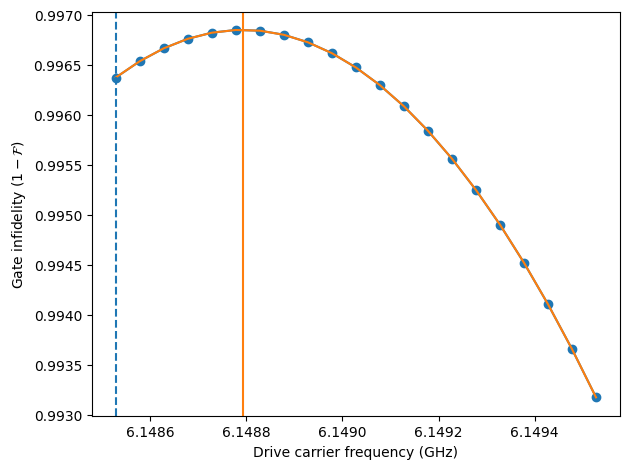

In [30]:
plt.plot(carrier_freqs, fidelities, "-o")
plt.plot(
    carrier_freqs,
    polyfit_result[0] * carrier_freqs**2
    + polyfit_result[1] * carrier_freqs
    + polyfit_result[2],
)
plt.axvline(optimal_freq, c="C1")
plt.axvline(device.qubits[0].frequency, ls="--")
plt.xlabel("Drive carrier frequency (GHz)")
plt.ylabel(r"Gate infidelity $(1-\mathcal{F})$")
plt.tight_layout()

In [31]:
optimal_freq

6.148792591721474

In [32]:
fidelities_drag = []
for drag_param_idx in range(len(drag_params)):
    PTM = metrajs_ptm_drag[drag_param_idx, :, :]
    fidel = gate_fidelity(PTM, target_ptm_op=target_ptm_op)
    fidelities_drag.append(fidel)
fidelities_drag = np.array(fidelities_drag)

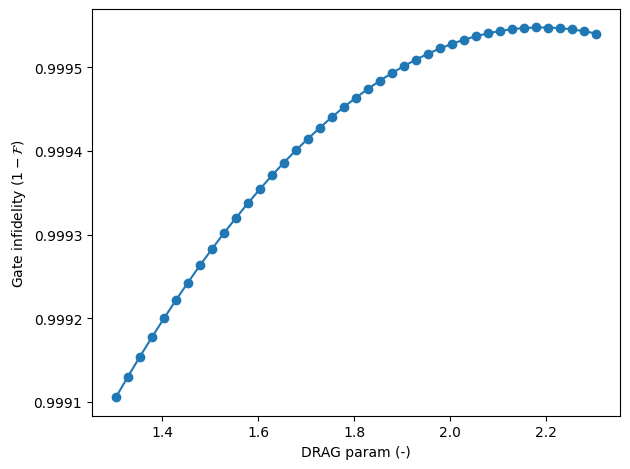

In [33]:
plt.plot(drag_params, fidelities_drag, "-o")
# plt.plot(
#     carrier_freqs,
#     polyfit_result[0] * carrier_freqs**2
#     + polyfit_result[1] * carrier_freqs
#     + polyfit_result[2],
# )
# plt.axvline(optimal_freq, c="C1")
# plt.axvline(device.qubits[0].frequency, ls="--")
plt.xlabel("DRAG param (-)")
plt.ylabel(r"Gate infidelity $(1-\mathcal{F})$")
plt.tight_layout()

# TODO: Rendu ici, plot the qubit populations and in-subspace XYZ trajectories, and |2> at the end of the gate for DRAG vs. Cosine

## Plot the results

In [34]:
metrajs_ptm[0, :, :].real.round(3)

Array([[ 1.   ,  0.   ,  0.   ,  0.   ],
       [-0.   ,  0.989, -0.001,  0.146],
       [-0.   ,  0.001, -1.   , -0.008],
       [ 0.   ,  0.146,  0.009, -0.989]], dtype=float64)

In [35]:
metrajs_ptm_drag[0, :, :].real.round(3)

Array([[ 1.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.997, -0.05 ,  0.051],
       [-0.   , -0.05 , -0.999, -0.01 ],
       [ 0.   ,  0.052,  0.008, -0.999]], dtype=float64)

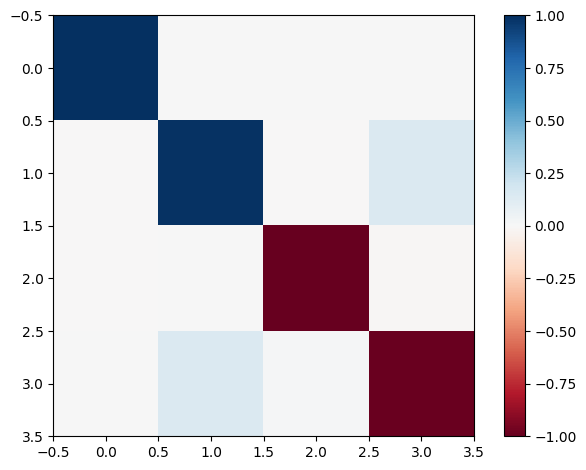

In [36]:
plt.imshow(metrajs_ptm[0, :, :].real, vmin=-1, vmax=1, cmap='RdBu')
plt.colorbar()
plt.tight_layout()

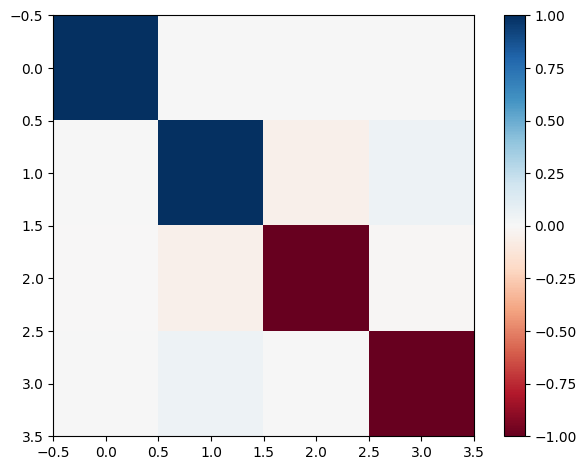

In [37]:
plt.imshow(metrajs_ptm_drag[0, :, :].real, vmin=-1, vmax=1, cmap="RdBu")
plt.colorbar()
plt.tight_layout()

# Old implementation

In [38]:
GATE_TIME_NS = 30 * ns
AMPLITUDE_GHZ = (2 * math.pi) / GATE_TIME_NS / float(jnp.abs(transmon.charge_zpf))
# CARRIER_FREQ_GHZ = float(transmon.frequency)
CARRIER_FREQ_GHZ = jnp.linspace(transmon.frequency, transmon.frequency+0.001, 21)
CARRIER_PHASE = 0.0
DRAG_PARAM = 1 / 4 / (-float(transmon.anharmonicity))

# transmon.drives["cosine_drive"].set_params(
#     amplitude_GHz=AMPLITUDE_GHZ,
#     gate_time_ns=GATE_TIME_NS,
#     # carrier_freq_GHz=CARRIER_FREQ_GHZ,
#     carrier_phase=CARRIER_PHASE,
# )

AMPLITUDE_GHZ, CARRIER_FREQ_GHZ

(0.022735030372498355,
 Array([6.14852788, 6.14857788, 6.14862788, 6.14867788, 6.14872788,
        6.14877788, 6.14882788, 6.14887788, 6.14892788, 6.14897788,
        6.14902788, 6.14907788, 6.14912788, 6.14917788, 6.14922788,
        6.14927788, 6.14932788, 6.14937788, 6.14942788, 6.14947788,
        6.14952788], dtype=float64))

## Device

In [39]:
device = Device(
    [
        transmon,
    ]
)

device.index_eigenstates()

device.diagonalize()

ValueError: Qubit Q1 is already embedded into a larger Hilbert space.Please ensure that qubits are not already part of a device.

## Dynamiqs Hamiltonian

In [ ]:
CARRIER_FREQ_GHZ

Array([6.14852788, 6.14857788, 6.14862788, 6.14867788, 6.14872788,
       6.14877788, 6.14882788, 6.14887788, 6.14892788, 6.14897788,
       6.14902788, 6.14907788, 6.14912788, 6.14917788, 6.14922788,
       6.14927788, 6.14932788, 6.14937788, 6.14942788, 6.14947788,
       6.14952788], dtype=float64)

In [ ]:
def build_dynamiqs_hamiltonian(device: Device):
    dq_hamiltonian = dq.constant(device.get_hamiltonian())
    for prefactor, operator in device.get_drive_hamiltonian_terms():
        dq_hamiltonian = dq_hamiltonian + dq.modulated(
            prefactor,
            operator,
            args=(
                AMPLITUDE_GHZ,
                GATE_TIME_NS,
                CARRIER_FREQ_GHZ,
                DRAG_PARAM,
                CARRIER_PHASE,
            ),
        )
    return dq_hamiltonian

In [ ]:
for prefactor, operator in device.get_drive_hamiltonian_terms():
    print(prefactor.keywords)

{}


In [ ]:
prefactor.func

<function blueprint.pulses.charge_pulses.cosine_drag_pulse(t: float, amplitude_GHz: float, gate_time_ns: float, carrier_freq_GHz: float, drag_param: float, carrier_phase: float) -> jax.Array>

In [ ]:
dq_hamiltonian = build_dynamiqs_hamiltonian(device=device)

In [ ]:
dq_hamiltonian.timearrays[1].args

(0.022735030372498355,
 188.49555921538757,
 Array([6.14852788, 6.14857788, 6.14862788, 6.14867788, 6.14872788,
        6.14877788, 6.14882788, 6.14887788, 6.14892788, 6.14897788,
        6.14902788, 6.14907788, 6.14912788, 6.14917788, 6.14922788,
        6.14927788, 6.14932788, 6.14937788, 6.14942788, 6.14947788,
        6.14952788], dtype=float64),
 1.3033166893355952,
 0.0)

In [ ]:
dq_hamiltonian(0.0).shape

(21, 5, 5)

# Single-qubit gate simulations

## Define the scope

In [ ]:
# === tsave
tsave = jnp.linspace(0, GATE_TIME_NS, 31)

In [ ]:
# === qubit operators and states
ket_0 = device.get_eigenstate(0)[1][:, None]
ket_1 = device.get_eigenstate(1)[1][:, None]
ket_2 = device.get_eigenstate(2)[1][:, None]
ket_3 = device.get_eigenstate(3)[1][:, None]

Id = ket_0 @ dq.dag(ket_0) + ket_1 @ dq.dag(ket_1)
X = ket_0 @ dq.dag(ket_1) + ket_1 @ dq.dag(ket_0)                 # X
Y = -1.0j * ket_0 @ dq.dag(ket_1) + 1.0j * ket_1 @ dq.dag(ket_0)  # Y
Z = ket_0 @ dq.dag(ket_0) - ket_1 @ dq.dag(ket_1)                 # Z

rho_pX = (Id + X) / 2
rho_mX = (Id - X) / 2
rho_pY = (Id + Y) / 2
rho_mY = (Id - Y) / 2
rho_pZ = (Id + Z) / 2
rho_mZ = (Id - Z) / 2

In [ ]:
# === initial states
rho0 = jnp.stack(
    [
        rho_pX,
        rho_mX,
        rho_pY,
        rho_mY,
        rho_pZ,
        rho_mZ,
        ket_2 @ dq.dag(ket_2),
        ket_3 @ dq.dag(ket_3),
    ]
)
rho0.shape

(8, 5, 5)

In [ ]:
from blueprint.operators.basis import OperatorBasis
from blueprint.util.operators import get_pauli_ops

In [ ]:
ops = jnp.stack(get_pauli_ops(normalize=True))
labels = ("I", "X", "Y", "Z")
basis = OperatorBasis(ops, labels)
basis = basis.expand_dim(device.dim)
basis.operators.shape

(4, 5, 5)

In [ ]:
# === expectation operators
# exp_ops = [
#     X,
#     Y,
#     Z,
#     ket_2 @ dq.dag(ket_2),
#     ket_3 @ dq.dag(ket_3)
# ]

In [ ]:
exp_ops = basis.operators

In [ ]:
jump_ops = [jnp.zeros((device.dim, device.dim))]

## Run the simulation

In [ ]:
import time

In [ ]:
# === run mesolve
t0 = time.time()
result = dq.mesolve(
    H=dq_hamiltonian,
    jump_ops=jump_ops,
    # rho0=rho0,
    rho0=basis.operators,
    tsave=tsave,
    # exp_ops=exp_ops,
    # exp_ops=basis.operators,
    # exp_ops=jnp.empty([]),
    solver=dq.solver.Tsit5(rtol=1e-06, atol=1e-06, max_steps=10000),
    options=dq.Options(
        save_states=True,
        verbose=True,
    ),
)
tf = time.time()
print(f"Sim took {tf - t0:.2f} seconds.")
print(result)

Sim took 4.66 seconds.
==== MEResult ====
Solver   : Tsit5
States   : Array complex128 (21, 4, 31, 5, 5) | 1017.19 Kb
Infos    : avg. 3394.9523809523807 steps (3385.083333333333 accepted, 9.869047619047619 rejected) | infos shape (21, 4)


## Get the expectation values in the qubit rotating frame

In [ ]:
# === expects in rotating frame
static_hamiltonian = device.get_hamiltonian()
if jnp.allclose(jnp.diag(jnp.diag(static_hamiltonian)), static_hamiltonian):
    U0s_diags = jnp.exp(
        1.0j * tsave[:, None] * jnp.diagonal(static_hamiltonian)[None, :]
    )
    # Now embed in diags
    Nt, Ndim = U0s_diags.shape
    U0s = (
        jnp.zeros_like(U0s_diags, shape=(Nt, Ndim, Ndim))
        .at[:, jnp.arange(Ndim), jnp.arange(Ndim)]
        .set(U0s_diags)
    )
else:
    # WARNING: Seems to be very error-prone for float32 (complex64) precision
    U0s = jax.scipy.linalg.expm(
        1.0j * tsave[:, None, None] * static_hamiltonian[None, :, :]
    )
# U0s: Shape ([time_len, *dims, *dims])
# result.states shape: (batch_size, time_len, *dims, *dims)
rhos_qb = U0s @ result.states @ dq.dag(U0s)
# rhos_qb = jnp.einsum('tnm,btmk->btnk', U0s, result.states)
# rhos_qb shape: (batch_size, time_len, *dims, *dims)
rhos_qb.shape

(21, 4, 31, 5, 5)

In [ ]:
# === expects in rotating frame
static_hamiltonian = device.get_hamiltonian()
if jnp.allclose(jnp.diag(jnp.diag(static_hamiltonian)), static_hamiltonian):
    U0s_diags = jnp.exp(
        1.0j * tsave[:, None] * jnp.diagonal(static_hamiltonian)[None, :]
    )
    # Now embed in diags
    Nt, Ndim = U0s_diags.shape
    U0s = (
        jnp.zeros_like(U0s_diags, shape=(Nt, Ndim, Ndim))
        .at[:, jnp.arange(Ndim), jnp.arange(Ndim)]
        .set(U0s_diags)
    )
else:
    # WARNING: Seems to be very error-prone for float32 (complex64) precision
    U0s = jax.scipy.linalg.expm(1.0j * tsave[:, None, None] * static_hamiltonian[None, :, :])
# U0s: Shape ([time_len, *dims, *dims])
# result.states shape: (batch_size, time_len, *dims, *dims)
rhos_qb = U0s @ result.states @ dq.dag(U0s)
# rhos_qb = jnp.einsum('tnm,btmk->btnk', U0s, result.states)
# rhos_qb shape: (*batch_sizes, time_len, *dims, *dims)

# exp_ops: Shape (n_expt_values, *dims, *dims)
metrajs = jnp.einsum("...tnm,emn->...et", rhos_qb, jnp.array(exp_ops)).real

In [ ]:
metrajs.shape

(21, 4, 4, 31)

## Gate fidelities

In [ ]:
from blueprint.metrics import gate_fidelity

In [ ]:
target_ptm_op = jnp.diag(jnp.array([1, 1, -1, -1]))
fidelities = []
for carrier_freq_idx in range(len(metrajs)):
    PTM = metrajs[carrier_freq_idx, :, :, -1]
    fidel = gate_fidelity(PTM, target_ptm_op=target_ptm_op)
    fidelities.append(fidel)
fidelities = np.array(fidelities)

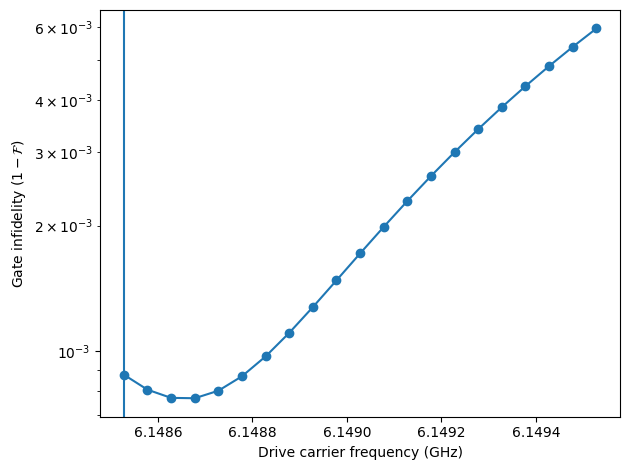

In [ ]:
plt.semilogy(CARRIER_FREQ_GHZ, 1-fidelities, '-o')
plt.axvline(device.qubits[0].frequency)
plt.xlabel("Drive carrier frequency (GHz)")
plt.ylabel(r"Gate infidelity $(1-\mathcal{F})$")
plt.tight_layout()

## Plot the results

In [ ]:
print(metrajs[0, :, :, -1].real)

[[ 9.99998064e-01  2.02114761e-06  4.31828560e-07  1.21175622e-05]
 [ 3.24348425e-07  9.97401242e-01 -2.17802619e-04  7.10286491e-02]
 [-2.46146723e-07  3.13760097e-04 -9.99908605e-01 -7.73687494e-03]
 [ 6.36787959e-06  7.09936710e-02  7.77053559e-03 -9.97437071e-01]]


In [ ]:
print(metrajs[0, :, :, -1].real.round(3))

[[ 1.     0.     0.     0.   ]
 [ 0.     0.997 -0.     0.071]
 [-0.     0.    -1.    -0.008]
 [ 0.     0.071  0.008 -0.997]]


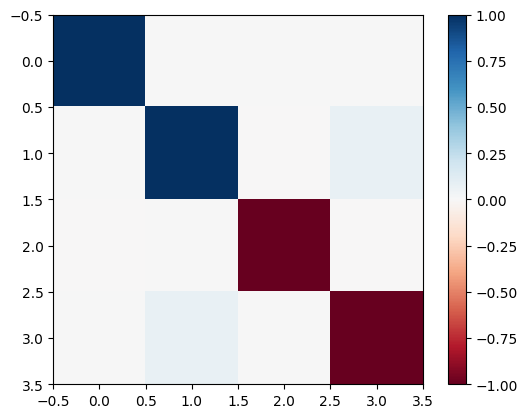

In [ ]:
plt.imshow(metrajs[0, :, :, -1].real, vmin=-1, vmax=1, cmap='RdBu')
plt.colorbar()

In [ ]:
from blueprint.metrics import gate_fidelity

In [ ]:
PTM = metrajs[0, :, :, -1].real

In [ ]:
jnp.all(jnp.isreal(PTM))

Array(True, dtype=bool)

In [ ]:
gate_fidelity(PTM, target_ptm_op=jnp.diag(jnp.array([1,1,-1,-1])))

0.9991241635241274

In [ ]:
jnp.diag(jnp.array([1, 1, -1, -1]))

Array([[ 1,  0,  0,  0],
       [ 0,  1,  0,  0],
       [ 0,  0, -1,  0],
       [ 0,  0,  0, -1]], dtype=int64)

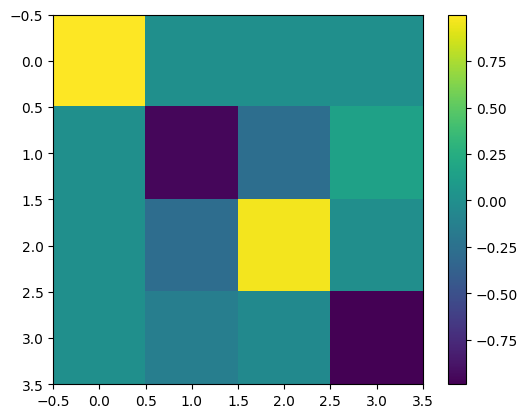

In [ ]:
plt.imshow(result.expects[:, :, -1].real)
plt.colorbar()

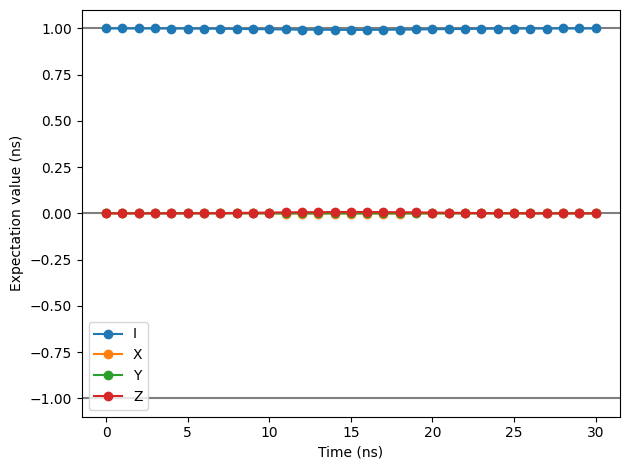

In [ ]:
pidx = 0
plt.plot(tsave / ns, metrajs[pidx, 0, :], "-o", label="I")
plt.plot(tsave / ns, metrajs[pidx, 1, :], "-o", label="X")
plt.plot(tsave / ns, metrajs[pidx, 2, :], "-o", label="Y")
plt.plot(tsave / ns, metrajs[pidx, 3, :], "-o", label="Z")
plt.axhline(0.0, ls="-", c="tab:gray", zorder=-1)
plt.axhline(1.0, ls="-", c="tab:gray", zorder=-1)
plt.axhline(-1.0, ls="-", c="tab:gray", zorder=-1)
plt.xlabel("Time (ns)")
plt.ylabel("Expectation value (ns)")
plt.legend()
plt.tight_layout()

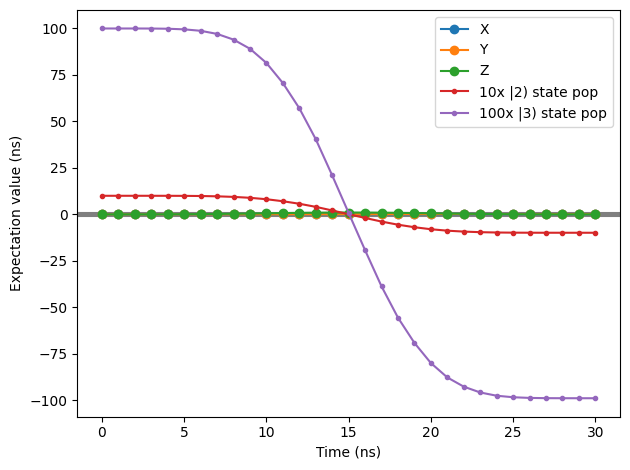

In [ ]:
pidx = 4
plt.plot(tsave / ns, metrajs[pidx, 0, :], "-o", label="X")
plt.plot(tsave / ns, metrajs[pidx, 1, :], "-o", label="Y")
plt.plot(tsave / ns, metrajs[pidx, 2, :], "-o", label="Z")
plt.plot(tsave / ns, 10 * metrajs[pidx, 3, :], ".-", label="10x |2) state pop")
plt.plot(tsave / ns, 100 * metrajs[pidx, 4, :], ".-", label="100x |3) state pop")
plt.axhline(0.0, ls="-", c="tab:gray", zorder=-1)
plt.axhline(1.0, ls="-", c="tab:gray", zorder=-1)
plt.axhline(-1.0, ls="-", c="tab:gray", zorder=-1)
plt.xlabel("Time (ns)")
plt.ylabel("Expectation value (ns)")
plt.legend()
plt.tight_layout()

We are getting slightly detuned Rabi oscillations because of the ac Start shift due to the microwave drive. Can test that this gets worse with decreasing the gate length (effectively increasing the drive amplitude). Can calibrate the gate by adjusting the detuning of the carrier_freq such that omega_01 + ac_detuning is on resonance with the drive.

We are also effectively driving around -sigma_X, which is expected according to my math. Could easily fix it such that a positive I/Q quadrature driving (prefacor of cos(w_d * t)) is driving around +X/+Y as in textbook implementation.

We see about 1% leakage here for 30ns gate without DRAG, and it gets much worse with faster gates.

# TODO: Scan a gate parameter and batch mesolve()

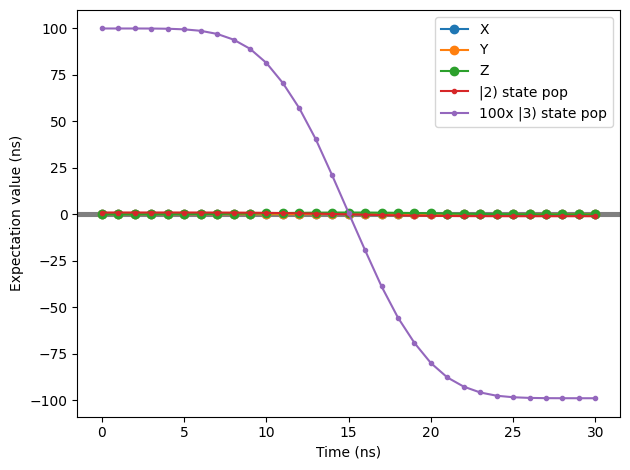

In [ ]:
pidx = 6
plt.plot(tsave / ns, metrajs[pidx, 0, :], "-o", label="X")
plt.plot(tsave / ns, metrajs[pidx, 1, :], "-o", label="Y")
plt.plot(tsave / ns, metrajs[pidx, 2, :], "-o", label="Z")
plt.plot(tsave / ns, metrajs[pidx, 3, :], ".-", label="|2) state pop")
plt.plot(tsave / ns, 100 * metrajs[pidx, 4, :], ".-", label="100x |3) state pop")
plt.axhline(0.0, ls="-", c="tab:gray", zorder=-1)
plt.axhline(1.0, ls="-", c="tab:gray", zorder=-1)
plt.axhline(-1.0, ls="-", c="tab:gray", zorder=-1)
plt.xlabel("Time (ns)")
plt.ylabel("Expectation value (ns)")
plt.legend()
plt.tight_layout()

# TODO: Try the DRAG cosine pulse version and compare leakage to not DRAG

# Test the simple drive

In [ ]:
times = jnp.linspace(0, GATE_TIME_NS, 201)
all_drive_amps = np.zeros((len(times),))
for t_idx, t in enumerate(times):
    hamil = dq_hamiltonian(t)
    all_drive_amps[t_idx] = float(hamil[0, 1].real)

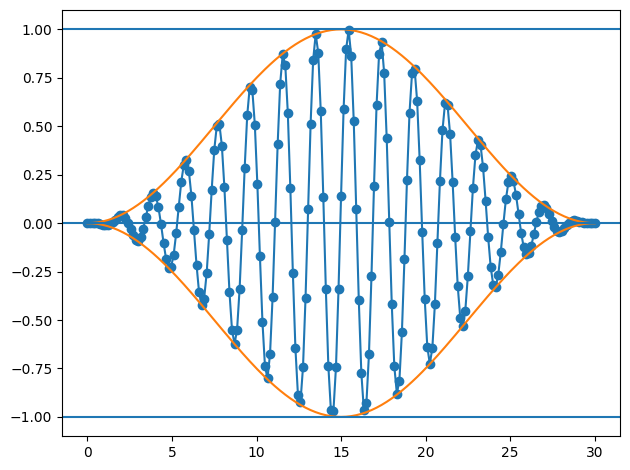

In [ ]:
plt.plot(times / ns, all_drive_amps / transmon.charge_zpf / AMPLITUDE_GHZ, "-o")
plt.plot(times / ns, (1 - jnp.cos(2 * jnp.pi / GATE_TIME_NS * times)) / 2, "-", c="C1")
plt.plot(times / ns, -(1 - jnp.cos(2 * jnp.pi / GATE_TIME_NS * times)) / 2, "-", c="C1")
plt.axhline(0.)
plt.axhline(1.0)
plt.axhline(-1.0)
plt.tight_layout()